# Import the required libraries

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Import the dataset

In [75]:
dataset = pd.read_csv("ai_job_market.csv")

In [76]:
dataset.head()

,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred
0,1,Foster and Sons,Healthcare,Data Analyst,"NumPy, Reinforcement Learning, PyTorch, Scikit...",Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,Large,"KDB+, LangChain"
1,2,"Boyd, Myers and Ramirez",Tech,Computer Vision Engineer,"Scikit-learn, CUDA, SQL, Pandas",Senior,Full-time,"Lake Scott, CU",78523-144875,2024-03-22,Large,"FastAPI, KDB+, TensorFlow"
2,3,King Inc,Tech,Quant Researcher,"MLflow, FastAPI, Azure, PyTorch, SQL, GCP",Entry,Full-time,"East Paige, CM",124496-217204,2025-09-18,Large,"BigQuery, PyTorch, Scikit-learn"
3,4,"Cooper, Archer and Lynch",Tech,AI Product Manager,"Scikit-learn, C++, Pandas, LangChain, AWS, R",Mid,Full-time,"Perezview, FI",50908-123743,2024-05-08,Large,"TensorFlow, BigQuery, MLflow"
4,5,Hall LLC,Finance,Data Scientist,"Excel, Keras, SQL, Hugging Face",Senior,Contract,"North Desireeland, NE",98694-135413,2025-02-24,Large,"PyTorch, LangChain"


In [77]:
dataset.shape

(2000, 12)

In [78]:
dataset.isnull().sum()

job_id              0
company_name        0
industry            0
job_title           0
skills_required     0
experience_level    0
employment_type     0
location            0
salary_range_usd    0
posted_date         0
company_size        0
tools_preferred     0
dtype: int64

In [79]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   job_id            2000 non-null   int64 
 1   company_name      2000 non-null   object
 2   industry          2000 non-null   object
 3   job_title         2000 non-null   object
 4   skills_required   2000 non-null   object
 5   experience_level  2000 non-null   object
 6   employment_type   2000 non-null   object
 7   location          2000 non-null   object
 8   salary_range_usd  2000 non-null   object
 9   posted_date       2000 non-null   object
 10  company_size      2000 non-null   object
 11  tools_preferred   2000 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.6+ KB


In [80]:
dataset.describe

<bound method NDFrame.describe of       job_id                   company_name    industry  \
0          1                Foster and Sons  Healthcare   
1          2        Boyd, Myers and Ramirez        Tech   
2          3                       King Inc        Tech   
3          4       Cooper, Archer and Lynch        Tech   
4          5                       Hall LLC     Finance   
...      ...                            ...         ...   
1995    1996       Mueller, Ellis and Clark     Finance   
1996    1997                     Roberts-Yu  Automotive   
1997    1998  Brooks, Williams and Randolph   Education   
1998    1999                Castaneda-Smith   Education   
1999    2000                    Estes Group     Finance   

                     job_title  \
0                 Data Analyst   
1     Computer Vision Engineer   
2             Quant Researcher   
3           AI Product Manager   
4               Data Scientist   
...                        ...   
1995              N

In [81]:
dataset.value_counts("industry")

industry
Automotive    300
Education     294
Retail        293
E-commerce    291
Finance       279
Tech          274
Healthcare    269
Name: count, dtype: int64

In [82]:
dataset.value_counts("job_title")

job_title
Data Analyst                271
NLP Engineer                265
AI Product Manager          258
Quant Researcher            251
ML Engineer                 250
Data Scientist              238
AI Researcher               237
Computer Vision Engineer    230
Name: count, dtype: int64

In [83]:
dataset.duplicated().sum()

0

# Data Preprocessing

In [84]:
dataset.head(10)

,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred
0,1,Foster and Sons,Healthcare,Data Analyst,"NumPy, Reinforcement Learning, PyTorch, Scikit...",Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,Large,"KDB+, LangChain"
1,2,"Boyd, Myers and Ramirez",Tech,Computer Vision Engineer,"Scikit-learn, CUDA, SQL, Pandas",Senior,Full-time,"Lake Scott, CU",78523-144875,2024-03-22,Large,"FastAPI, KDB+, TensorFlow"
2,3,King Inc,Tech,Quant Researcher,"MLflow, FastAPI, Azure, PyTorch, SQL, GCP",Entry,Full-time,"East Paige, CM",124496-217204,2025-09-18,Large,"BigQuery, PyTorch, Scikit-learn"
3,4,"Cooper, Archer and Lynch",Tech,AI Product Manager,"Scikit-learn, C++, Pandas, LangChain, AWS, R",Mid,Full-time,"Perezview, FI",50908-123743,2024-05-08,Large,"TensorFlow, BigQuery, MLflow"
4,5,Hall LLC,Finance,Data Scientist,"Excel, Keras, SQL, Hugging Face",Senior,Contract,"North Desireeland, NE",98694-135413,2025-02-24,Large,"PyTorch, LangChain"
5,6,Ellis PLC,E-commerce,AI Product Manager,"GCP, Excel, Scikit-learn, MLflow",Senior,Remote,"South Kevin, TZ",92632-180718,2025-08-07,Large,"PyTorch, TensorFlow, FastAPI"
6,7,Matthews-Moses,Automotive,Data Analyst,"Python, Flask, Scikit-learn, GCP",Mid,Full-time,"West Shawn, LR",70575-88594,2024-12-23,Large,"PyTorch, MLflow"
7,8,Mullins Ltd,Education,Data Scientist,"Excel, SQL, Flask",Entry,Internship,"Port Hailey, RU",63032-82144,2024-08-14,Large,BigQuery
8,9,Aguilar PLC,Healthcare,ML Engineer,"Pandas, LangChain, GCP, Azure",Entry,Internship,"Butlermouth, GB",134239-188504,2025-09-15,Large,"Scikit-learn, LangChain, BigQuery"
9,10,Parks LLC,Automotive,Computer Vision Engineer,"Excel, Reinforcement Learning, TensorFlow",Senior,Full-time,"Nicoleshire, BA",79361-165029,2025-08-07,Large,"MLflow, TensorFlow"


In [85]:
dataset = dataset.dropna(subset=['job_title', 'skills_required', 'experience_level', 'industry', 'employment_type', 'company_size'])

* for skills_required column

In [86]:
from sklearn.preprocessing import MultiLabelBinarizer

In [87]:
skills_series = dataset['skills_required'].str.split(', ').explode().str.strip()
unique_skills_list = skills_series.value_counts().index.tolist()

In [88]:
mlb = MultiLabelBinarizer(classes=unique_skills_list)
skills_matrix = mlb.fit_transform(dataset['skills_required'].apply(lambda x: [s.strip() for s in str(x).split(',')]))
dataset['skills_array'] = skills_matrix.tolist()

In [89]:
skills_mapping = mlb.classes_.tolist()
print(skills_mapping)

['TensorFlow', 'Excel', 'Pandas', 'FastAPI', 'NumPy', 'Reinforcement Learning', 'Azure', 'Hugging Face', 'SQL', 'Keras', 'AWS', 'Power BI', 'GCP', 'Python', 'LangChain', 'PyTorch', 'Scikit-learn', 'Flask', 'CUDA', 'R', 'C++', 'MLflow']


In [90]:
row_1 = dataset.iloc[1]
print(f"Skills Array:{row_1['skills_array']}")

Skills Array:[0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0]


* for experience_level column

In [91]:
dataset.value_counts("experience_level")

experience_level
Entry     702
Mid       668
Senior    630
Name: count, dtype: int64

In [92]:
from sklearn.preprocessing import LabelBinarizer

In [93]:
lb_exp = LabelBinarizer()
exp_matrix = lb_exp.fit_transform(dataset['experience_level'])
dataset['experience_array'] = exp_matrix.tolist()

In [94]:
exp_mapping = lb_exp.classes_.tolist()
print(exp_mapping)

['Entry', 'Mid', 'Senior']


In [95]:
row_1 = dataset.iloc[1]
print(f"Experience Array:{row_1['experience_array']}")

Experience Array:[0, 0, 1]


* for industry column

In [96]:
dataset.value_counts("industry")

industry
Automotive    300
Education     294
Retail        293
E-commerce    291
Finance       279
Tech          274
Healthcare    269
Name: count, dtype: int64

In [97]:
lb_ind = LabelBinarizer()
ind_matrix = lb_ind.fit_transform(dataset['industry'])
dataset['industry_array'] = ind_matrix.tolist()

In [98]:
industry_mapping = lb_ind.classes_.tolist()
print(industry_mapping)

['Automotive', 'E-commerce', 'Education', 'Finance', 'Healthcare', 'Retail', 'Tech']


In [99]:
row_1 = dataset.iloc[1]
print(f"Industry 1st row:{row_1['industry_array']}")

Industry 1st row:[0, 0, 0, 0, 0, 0, 1]


* for employment_type

In [100]:
dataset.value_counts("employment_type")

employment_type
Internship    574
Full-time     509
Contract      465
Remote        452
Name: count, dtype: int64

In [101]:
lb_emp = LabelBinarizer()
emp_matrix = lb_emp.fit_transform(dataset['employment_type'])
dataset['employment_array'] = emp_matrix.tolist()

In [102]:
employment_mapping = lb_emp.classes_.tolist()
print(employment_mapping)

['Contract', 'Full-time', 'Internship', 'Remote']


In [103]:
row_1 = dataset.iloc[1]
print(f"Employment Type Array:{row_1['employment_array']}")

Employment Type Array:[0, 1, 0, 0]


* for company_size column

In [104]:
dataset.value_counts("company_size")

company_size
Startup    672
Mid        671
Large      657
Name: count, dtype: int64

In [105]:
lb_size = LabelBinarizer()
size_matrix = lb_size.fit_transform(dataset['company_size'])
dataset['size_array'] = size_matrix.tolist()

In [106]:
size_mapping = lb_size.classes_.tolist()
print(size_mapping)

['Large', 'Mid', 'Startup']


In [107]:
row_1 = dataset.iloc[1]
print(f"Company Size Array:{row_1['size_array']}")

Company Size Array:[1, 0, 0]


In [108]:
def combine_features(row):
    return np.array(
        row['skills_array'] +
        row['experience_array'] +
        row['industry_array'] +
        row['employment_array'] +
        row['size_array']
    )

dataset['features'] = dataset.apply(combine_features, axis=1)

In [109]:
X = np.vstack(dataset['features'].values)
y = dataset['job_title']

In [110]:
X

array([[0, 0, 0, ..., 1, 0, 0],
       [0, 0, 1, ..., 1, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 1, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [1, 0, 0, ..., 0, 0, 1]])

In [111]:
y

0                   Data Analyst
1       Computer Vision Engineer
2               Quant Researcher
3             AI Product Manager
4                 Data Scientist
                  ...           
1995                NLP Engineer
1996          AI Product Manager
1997                Data Analyst
1998            Quant Researcher
1999            Quant Researcher
Name: job_title, Length: 2000, dtype: object

### Encode Target(job_title)

In [112]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [113]:
y_encoded

array([3, 2, 7, ..., 3, 7, 7])

### Train Test Split

In [114]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

### Train Model - LogisticRegression 

In [115]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


### Train Model - Random Forest

In [116]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Model Evaluation 


Evaluating: Logistic Regression
 Accuracy: 0.135


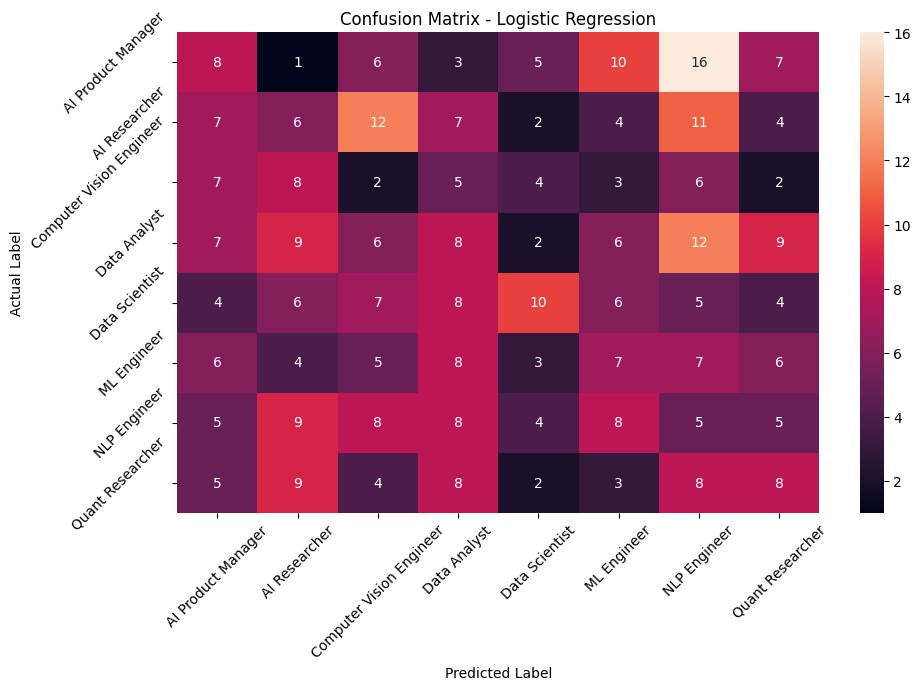


 Cross-validation scores: [0.1425 0.13   0.125  0.11   0.1325]
 Mean CV Accuracy: 0.12799999999999997

Evaluating: Random Forest
 Accuracy: 0.165


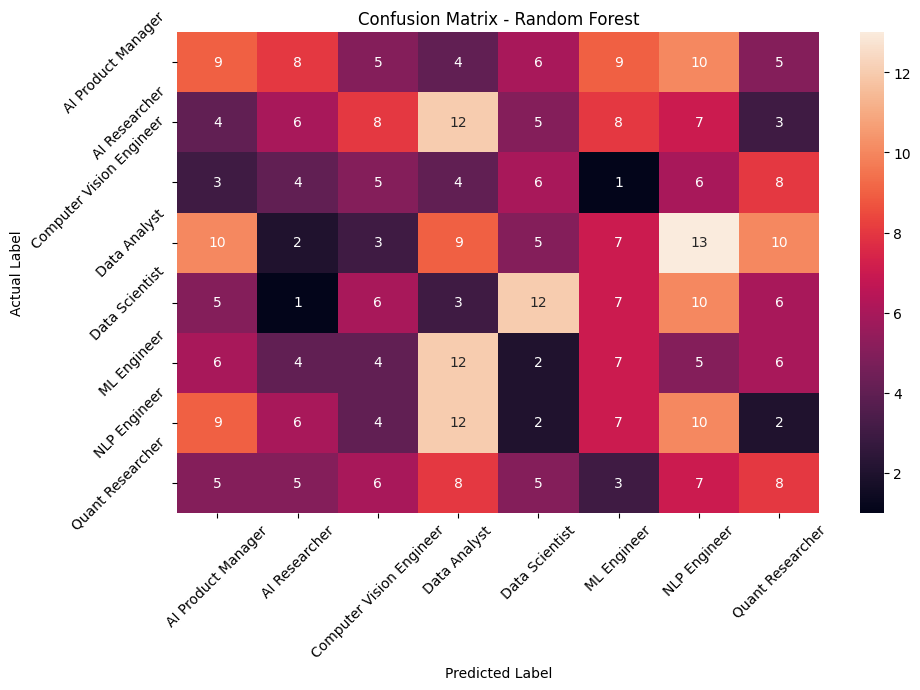


 Cross-validation scores: [0.11   0.145  0.1375 0.1475 0.15  ]
 Mean CV Accuracy: 0.138


In [117]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, model_name):
    
    print(f"\n{'='*40}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*40}")
    
    y_pred = model.predict(X_test)
    
    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(" Accuracy:", accuracy)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Cross Validation
    cv_scores = cross_val_score(model, X, y_encoded, cv=5)
    
    print("\n Cross-validation scores:", cv_scores)
    print(" Mean CV Accuracy:", cv_scores.mean())


# Logistic Regression
evaluate_model(lr, "Logistic Regression")

# Random Forest
evaluate_model(rf, "Random Forest")

### Hyperparameter Tuning

In [118]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define parameter
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Initialize model
rf = RandomForestClassifier(random_state=42)

# Grid Search
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',   
    n_jobs=-1,            
    verbose=2
)

# Train
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: 0.13125


### Evaluate Tuned Model

Tuned Model Accuracy: 0.17

 Classification Report (Tuned Model):
                          precision    recall  f1-score   support

      AI Product Manager       0.20      0.20      0.20        56
           AI Researcher       0.17      0.09      0.12        53
Computer Vision Engineer       0.13      0.14      0.13        37
            Data Analyst       0.19      0.19      0.19        59
          Data Scientist       0.34      0.20      0.25        50
             ML Engineer       0.10      0.11      0.10        46
            NLP Engineer       0.12      0.19      0.15        52
        Quant Researcher       0.19      0.23      0.21        47

                accuracy                           0.17       400
               macro avg       0.18      0.17      0.17       400
            weighted avg       0.18      0.17      0.17       400



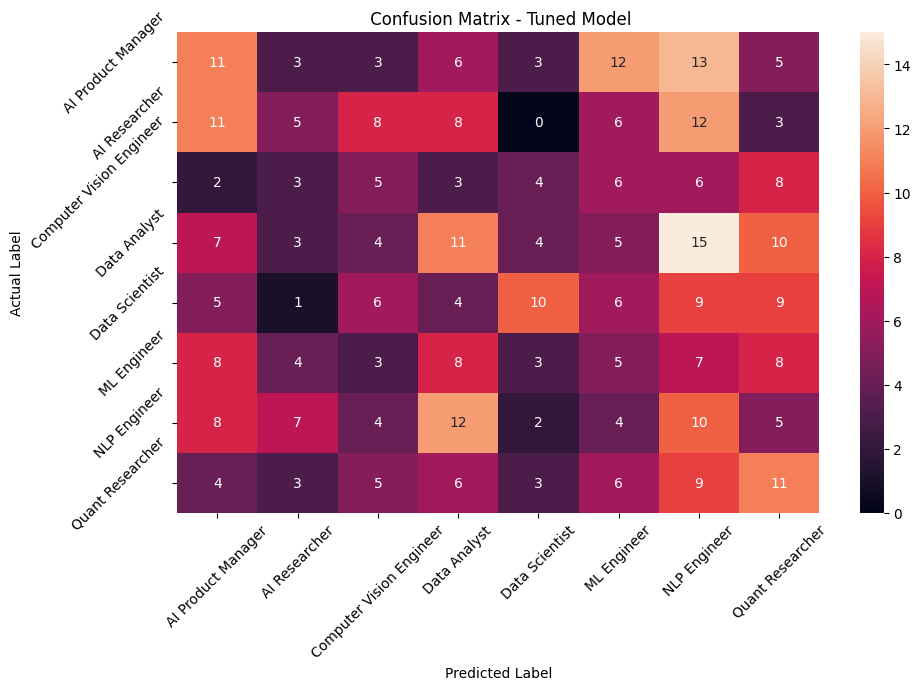

Tuned CV Scores: [0.09   0.14   0.1375 0.125  0.135 ]
Tuned Mean CV Accuracy: 0.1255


In [119]:
# Predict using tuned model
y_pred = best_model.predict(X_test)

#  Accuracy
print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\n Classification Report (Tuned Model):")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title(" Confusion Matrix - Tuned Model")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()
cv_scores = cross_val_score(best_model, X, y_encoded, cv=5)

print("Tuned CV Scores:", cv_scores)
print("Tuned Mean CV Accuracy:", cv_scores.mean())